In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from functions import Functions

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings

fname_zhou = '../data/CLIM_3D_forJenny.nc'
fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [4]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
extent = [138, 150,-68,-64]
extent2 = [139,142,-67,-66]

mertz = Region('Mertz',extent)
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


In [6]:
dscli = xr.open_dataset(fname_zhou)
dscli = dscli.squeeze().rename({'lat':'latitude','lon':'longitude','prs':'pressure'}) \
    .swap_dims({'NB_y':'latitude','NB_x':'longitude','NB_LEV':'pressure'})
dscli = fns.crop_to_extent(dscli,extent)


In [7]:
ds = pickle.load(open('c3data.pkl','rb'))
cdict = pickle.load(open('cdict.pkl','rb'))
en4 = xr.open_dataset('en4_analysis.nc')

In [8]:
en4['month'] = en4.time.dt.month
en4['year'] = en4.time.dt.year
en4_shelf = en4.sel(lat=slice(extent2[2],extent2[3]),lon=slice(extent2[0],extent2[1])).mean(['lat','lon'])

In [9]:
ds_shelf = ds.where(ds.elevation
                     > -1000,drop=True)

seasons_meop = fns.get_seasons(ds_shelf)
seasons_en4 = fns.get_seasons(en4_shelf)

In [10]:
# choose depth to average over
zz = 300

max_depth = ds_shelf.pres.where(~np.isnan(ds_shelf.temp)).max(dim="pres")
ds_z = ds_shelf.where(max_depth > zz,drop=True).sel(pres=slice(0,zz))
en4_z = en4_shelf.sel(depth=slice(0,zz))


In [11]:
n_min = 10

ds_zz = ds_z.mean('pres')
en4_zz = en4_z.mean('depth')
mon_mean_ = ds_zz.resample({'time':'MS'}).mean()
mon_std = ds_zz.resample({'time':'MS'}).std()
mon_count = ds_zz.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean = mon_mean_.where(mon_count > n_min, drop=True)
mon_std = mon_std.where(mon_count > n_min, drop=True)

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

In [12]:
mon_mean

<xarray.Dataset> Size: 3kB
Dimensions:    (time: 35)
Coordinates:
  * time       (time) datetime64[ns] 280B 2007-02-01 2007-03-01 ... 2024-02-01
Data variables:
    temp       (time) float64 280B -1.229 -1.707 -1.706 ... -1.876 -1.836 -1.491
    psal       (time) float64 280B 34.19 34.2 34.39 34.44 ... 34.61 34.57 34.24
    mld        (time) float64 280B 46.53 176.9 132.3 92.21 ... nan nan nan nan
    asal       (time) float32 140B 34.35 34.36 34.55 34.6 ... nan nan nan nan
    ctemp      (time) float32 140B -1.226 -1.704 -1.702 -1.749 ... nan nan nan
    rho        (time) float32 140B 1.028e+03 1.028e+03 1.028e+03 ... nan nan nan
    mlp        (time) float64 280B 42.55 172.1 123.9 82.53 ... nan nan nan nan
    gph        (time) float64 280B nan nan nan nan nan ... nan nan nan nan nan
    elevation  (time) float64 280B -309.7 -347.2 -580.7 ... -347.6 -367.2 -434.3
    month      (time) float64 280B 2.0 3.0 4.0 5.0 12.0 ... 5.0 6.0 8.0 9.0 2.0
    year       (time) float64 280B 2.007e+03 2.007e+03 ... 2.023e+03 2.024e+03
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [13]:
en4_shelf_likemeop = en4_shelf.broadcast_like(mon_mean.time)
en4_zz_likemeop = en4_zz.drop_dims('bnds').interp(time=mon_mean.time)

In [14]:
en4_zz

<xarray.Dataset> Size: 19kB
Dimensions:                          (time: 216, bnds: 2)
Coordinates:
  * time                             (time) datetime64[ns] 2kB 2007-01-16T12:...
Dimensions without coordinates: bnds
Data variables:
    temperature                      (time) float64 2kB 272.4 272.0 ... 271.4
    salinity                         (time) float64 2kB 34.34 34.13 ... 34.32
    temperature_uncertainty          (time) float64 2kB 0.2226 0.1734 ... 0.2714
    salinity_uncertainty             (time) float64 2kB 0.06771 ... 0.06734
    temperature_observation_weights  (time) float32 864B 0.8886 ... 0.8155
    salinity_observation_weights     (time) float32 864B 0.7761 ... 0.7888
    time_bnds                        (time, bnds) datetime64[ns] 3kB 2007-01-...
    depth_bnds                       (time, bnds) float32 2kB 102.5 ... 117.9
    month                            (time) int64 2kB 1 2 3 4 5 ... 8 9 10 11 12
    year                             (time) int64 2kB 2007 2007 ... 2024 2024
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

In [15]:
en4_zz_likemeop

<xarray.Dataset> Size: 3kB
Dimensions:                          (time: 35)
Coordinates:
  * time                             (time) datetime64[ns] 280B 2007-02-01 .....
Data variables:
    temperature                      (time) float64 280B 272.1 271.7 ... 271.9
    salinity                         (time) float64 280B 34.23 34.16 ... 34.27
    temperature_uncertainty          (time) float64 280B 0.1967 ... 0.2208
    salinity_uncertainty             (time) float64 280B 0.06263 ... 0.06143
    temperature_observation_weights  (time) float64 280B 0.9311 ... 0.9114
    salinity_observation_weights     (time) float64 280B 0.8676 0.966 ... 0.9021
    month                            (time) float64 280B 1.525 2.475 ... 1.517
    year                             (time) float64 280B 2.007e+03 ... 2.024e+03
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

In [16]:
cli_count = mon_mean.groupby('time.month').count()

cli_mean = mon_mean.groupby('time.month').mean()
cli_std = mon_mean.groupby('time.month').std()

cli_mean = cli_mean.where(cli_count.temp > 1,drop=True)
cli_std = cli_std.where(cli_count.temp >1,drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/

In [17]:
df=mon_mean.groupby('time.month').where(cli_count.temp > 1).to_dataframe()

In [18]:
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
month_values = xr.DataArray(np.arange(1,13),coords={'month':np.arange(1,13)})

In [ ]:
cdict = 

<xarray.Dataset> Size: 19kB
Dimensions:                          (time: 216, bnds: 2)
Coordinates:
  * time                             (time) datetime64[ns] 2kB 2007-01-16T12:...
Dimensions without coordinates: bnds
Data variables:
    temperature                      (time) float64 2kB 272.4 272.0 ... 271.4
    salinity                         (time) float64 2kB 34.34 34.13 ... 34.32
    temperature_uncertainty          (time) float64 2kB 0.2226 0.1734 ... 0.2714
    salinity_uncertainty             (time) float64 2kB 0.06771 ... 0.06734
    temperature_observation_weights  (time) float32 864B 0.8886 ... 0.8155
    salinity_observation_weights     (time) float32 864B 0.7761 ... 0.7888
    time_bnds                        (time, bnds) datetime64[ns] 3kB 2007-01-...
    depth_bnds                       (time, bnds) float32 2kB 102.5 ... 117.9
    month                            (time) int64 2kB 1 2 3 4 5 ... 8 9 10 11 12
    year                             (time) int64 2kB 2007 2007 ... 2024 2024
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this ob

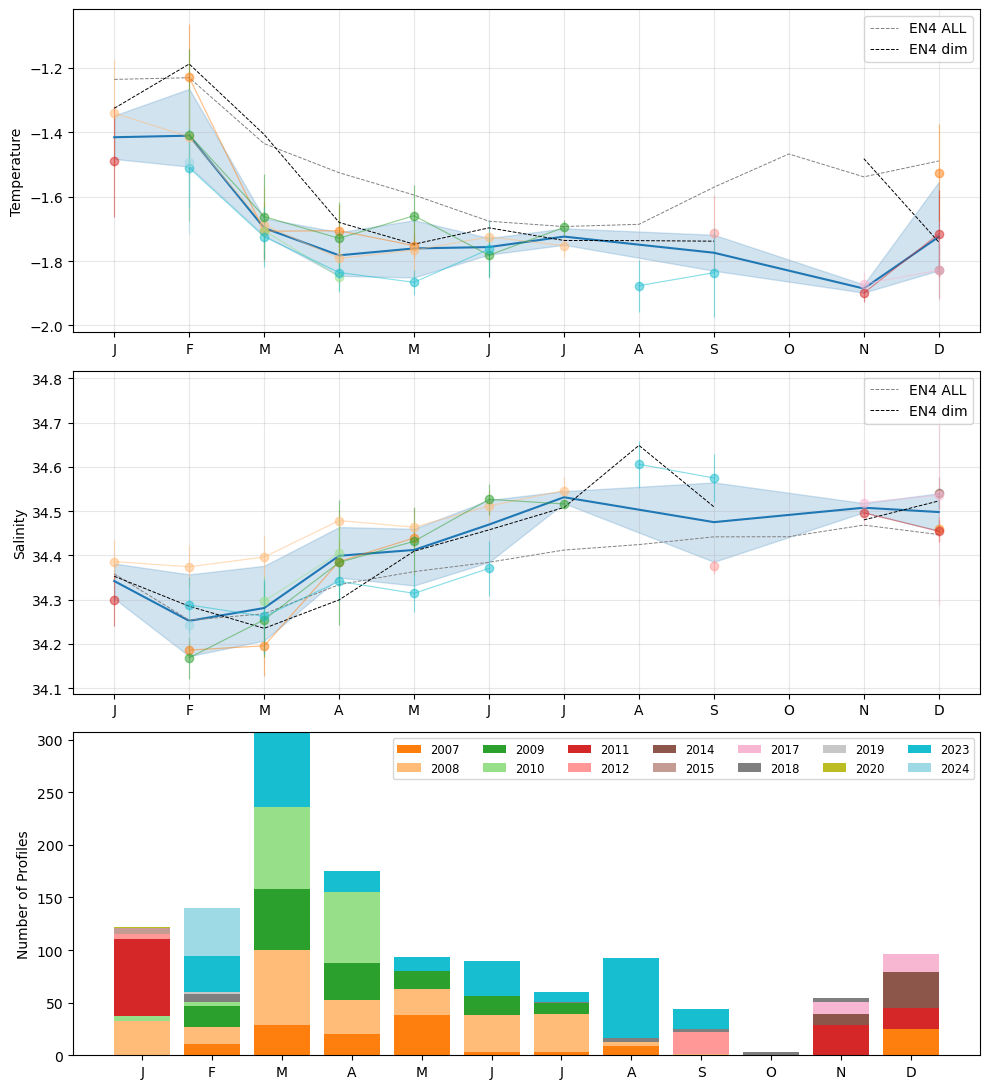

In [20]:
# # plot to demonstrate types of variailty
# dscrop = ds_400.sel(time=slice(pd.Timestamp(2007,1,1),pd.Timestamp(2008,1,1)))
# dscropmon = dscrop.groupby('time.month').mean()
# dscropmonstd = dscrop.groupby('time.month').std()

# fig,axs = plt.subplots(2,1,figsize=(10,5))
# ax=axs[0]
# ax.scatter(dscrop.month,dscrop.temp)
# ax.errorbar(dscropmon.month,dscropmon.temp,yerr=dscropmonstd.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# ax=axs[1]
# ax.scatter(mon_mean.month,mon_mean.temp)
# ax.errorbar(cli_mean.month,cli_mean.temp,yerr=cli_std.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# plt.tight_layout()

# mnothly variability plot
fig,axs = plt.subplots(3,1,figsize=(10,11))
mon_year = mon_mean.groupby('time.year').mean()
moc_year = mon_count.where(mon_count.temp).groupby('time.year').count()


ax=axs[0]
cx=axs[1]
bx=axs[2]

for y_da in moc_year.year:
    y = y_da.item()
    data = mon_mean.where(mon_mean.year==y,drop=True)
    dats = mon_std.where(mon_mean.year==y,drop=True)

    if not len(data.time) ==0:
        clim = data.groupby('time.month').mean().broadcast_like(month_values)
        clis = dats.groupby('time.month').mean().broadcast_like(month_values)

        # temperature
        ax.errorbar(clim.month,clim.temp,yerr=clis.temp,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])
        
        # salinity
        cx.errorbar(clim.month,clim.psal,yerr=clis.psal,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])

    # histogram
    year_count = mon_count.temp.where(mon_mean_.year==y,drop=True)
    if len(year_count) > 0:
        year_count = np.nan_to_num(year_count.groupby('time.month').mean().broadcast_like(month_values))
        if y > 2007:
            bx.bar(month_values, year_count, bottom = bottom,color=cdict[y],label=str(y))
            bottom = bottom + year_count
        else:
            bx.bar(month_values, year_count,color=cdict[y],label=str(y))
            bottom = year_count.copy()
        

#ax.legend(loc='best',fontsize=2)
bx.legend(ncol=7,fontsize='small')
bx.set_ylabel('Number of Profiles')
bx.set_xticks(np.arange(1,13),labels=month_labels)


sns.lineplot(
    data=df,
    x="month", y="temp", errorbar=("pi",90), ax=ax, 
)

en4_mean = en4_zz.temperature.groupby('time.month').mean()-273.15
en4_lm_mean = en4_zz_likemeop.temperature.groupby('time.month').mean().broadcast_like(month_values)-273.15

en4_unce = en4_zz.temperature_uncertainty.groupby('time.month').mean()
en4_lm_unce = en4_zz_likemeop.temperature_uncertainty.groupby('time.month').mean().broadcast_like(month_values)

ax.plot(month_values,en4_mean,label='EN4 ALL',ls='--',linewidth=0.7,c='grey')
#ax.fill_between(month_values, en4_mean - en4_unce, en4_mean + en4_unce, alpha=0.3)

ax.plot(month_values,en4_lm_mean,label='EN4 dim',ls='--',linewidth=0.7,c='k')
#ax.fill_between(month_values, en4_lm_mean - en4_lm_unce, en4_lm_mean + en4_lm_unce, alpha=0.3)
        
sns.lineplot(
    data=df,
    x="month", y="psal", errorbar=("pi",90), ax=cx
)

en4_mean = en4_zz.salinity.groupby('time.month').mean()
en4_lm_mean = en4_zz_likemeop.salinity.groupby('time.month').mean().broadcast_like(month_values)

en4_unce = en4_zz.salinity_uncertainty.groupby('time.month').mean()
en4_lm_unce = en4_zz_likemeop.salinity_uncertainty.groupby('time.month').mean().broadcast_like(month_values)

cx.plot(month_values,en4_mean,label='EN4 ALL',ls='--',linewidth=0.7,c='grey')
#ax.fill_between(month_values, en4_mean - en4_unce, en4_mean + en4_unce, alpha=0.3)

cx.plot(month_values,en4_lm_mean,label='EN4 dim',ls='--',linewidth=0.7,c='k')
#ax.fill_between(month_values, en4_lm_mean - en4_lm_unce, en4_lm_mean + en4_lm_unce, alpha=0.3)

ax.grid(alpha=0.3)
ax.set_xticks(np.arange(1,13),labels=month_labels)
ax.set_ylabel('Temperature')
ax.set_xlabel(None)
ax.legend()

cx.grid(alpha=0.3)
cx.set_xticks(np.arange(1,13),labels=month_labels)
cx.set_ylabel('Salinity')
cx.set_xlabel(None)
cx.legend()

plt.tight_layout()



In [21]:
mon_mean = ds_shelf.resample({'time':'MS'}).mean()
mon_std = ds_shelf.resample({'time':'MS'}).std()
mon_quants = ds_shelf.drop_vars(['dsource','profile_code']).resample({'time':'MS'}).quantile([0.1,0.9])
mon_iqr = mon_quants.sel(quantile=0.9) - mon_quants.sel(quantile=0.1)
mon_count = ds_shelf.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean = mon_mean.where(mon_count > n_min, drop=True)
mon_std = mon_std.where(mon_count > n_min, drop=True)
mon_iqr = mon_iqr.where(mon_count > n_min, drop=True)

cli_count = mon_mean.groupby('time.month').count().broadcast_like(cli_count)
cli_mean = mon_mean.groupby('time.month').mean().broadcast_like(cli_count)
cli_std = mon_mean.groupby('time.month').std().broadcast_like(cli_count)
cli_quants = mon_mean.drop_vars(['month']).groupby('time.month').quantile([0.1,0.9]).broadcast_like(cli_count)
cli_iqr = cli_quants.sel(quantile=0.9) - cli_quants.sel(quantile=0.1).broadcast_like(cli_count)




# make sure all months used have more than n profiles
# cli_mean = cli_mean.where(cli_count.temp > 1,drop=True)
# cli_std = cli_std.where(cli_count.temp >1,drop=True)
# cli_iqr = cli_iqr.where(cli_count.temp >1,drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

TypeError: Dimensions of C (11, 501) should be one smaller than X(12) and Y(502) while using shading='flat' see help(pcolor)

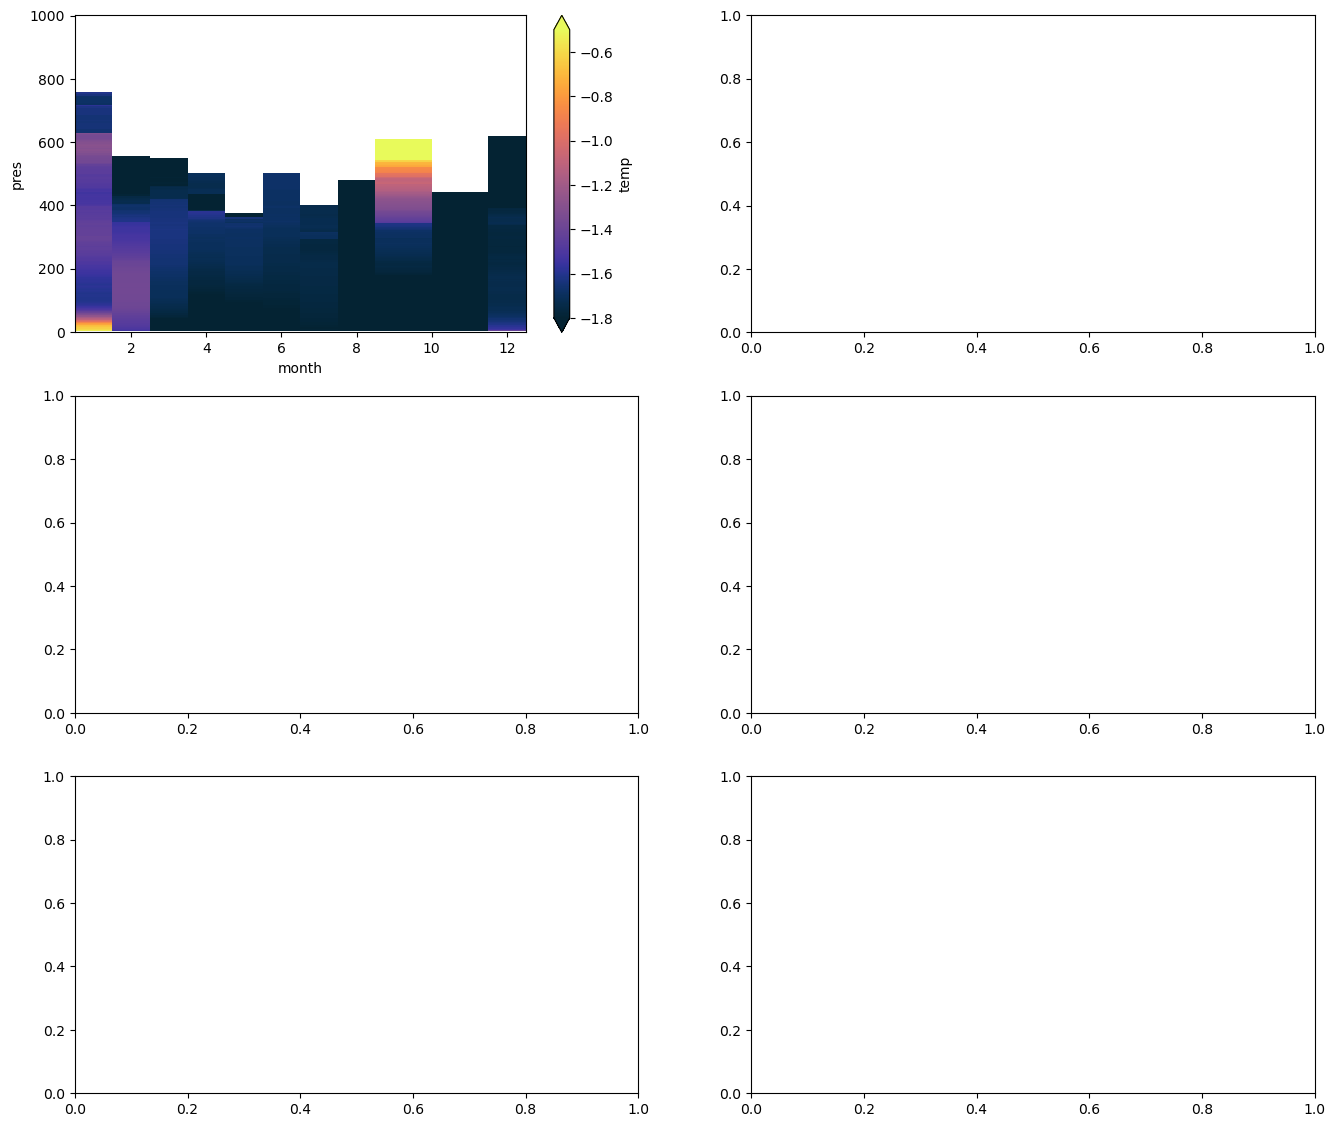

In [22]:
fig, ax = plt.subplots(3,2,figsize=(16,14))

mask = (cli_count.temp < 2) | np.isnan(cli_count.temp)

hatch_layer = xr.where(mask, 1, np.nan)

Z = hatch_layer.values

def edges(coord):
    c = coord.values
    d = np.diff(c)/2
    return np.concatenate(([c[0]-d[0]], c[:-1]+d, [c[-1]+d[-1]]))

Xe = edges(hatch_layer['month'])
Ye = edges(hatch_layer['pres'])

def presvmonth(ax,data,label,cmap,c1=None,c2=None):
    im=data.plot(ax=ax,x='month',y='pres',cmap=cmap,vmin=c1,vmax=c2)

    ax.pcolor(Xe, Ye, Z, #hatch_layer,
        alpha=0.01,
        hatch='xx'
    )
        
    ax.invert_yaxis()
    ax.set_ylabel('Pressure')
    im.colorbar.set_label(label)
    ax.set_xticks(np.arange(1,13),labels=month_labels)
    ax.set_xlabel(None)
    ax.set_ylim([500,0])


presvmonth(ax[0][0],cli_mean.temp,'Mean Temperature',cmap=cmocean.cm.thermal,c1=-1.8,c2=-0.5)
presvmonth(ax[0][1],cli_iqr.temp,'Temperature IQR90-10',cmocean.cm.thermal,c1=0,c2=0.75)

presvmonth(ax[1][0],cli_mean.psal,'Mean Salinity',cmap=cmocean.cm.haline,c1=33.9,c2=34.6)
presvmonth(ax[1][1],cli_iqr.psal,'Salinity IQR90-10',cmocean.cm.haline,c1=0,c2=0.45)

presvmonth(ax[2][0],cli_count.temp,'N. months',cmocean.cm.amp,c1=0,c2=5)
presvmonth(ax[2][1],mon_count.psal.groupby('time.month').sum(),'Total n. profiles',cmocean.cm.amp,c1=0,c2=500)


/tmp/ipykernel_1290419/839765754.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()],label=str(y.item())))
/tmp/ipykernel_1290419/839765754.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()],label=str(y.item())))
/tmp/ipykernel_1290419/839765754.py:8: UserWarning: *c* argument looks l

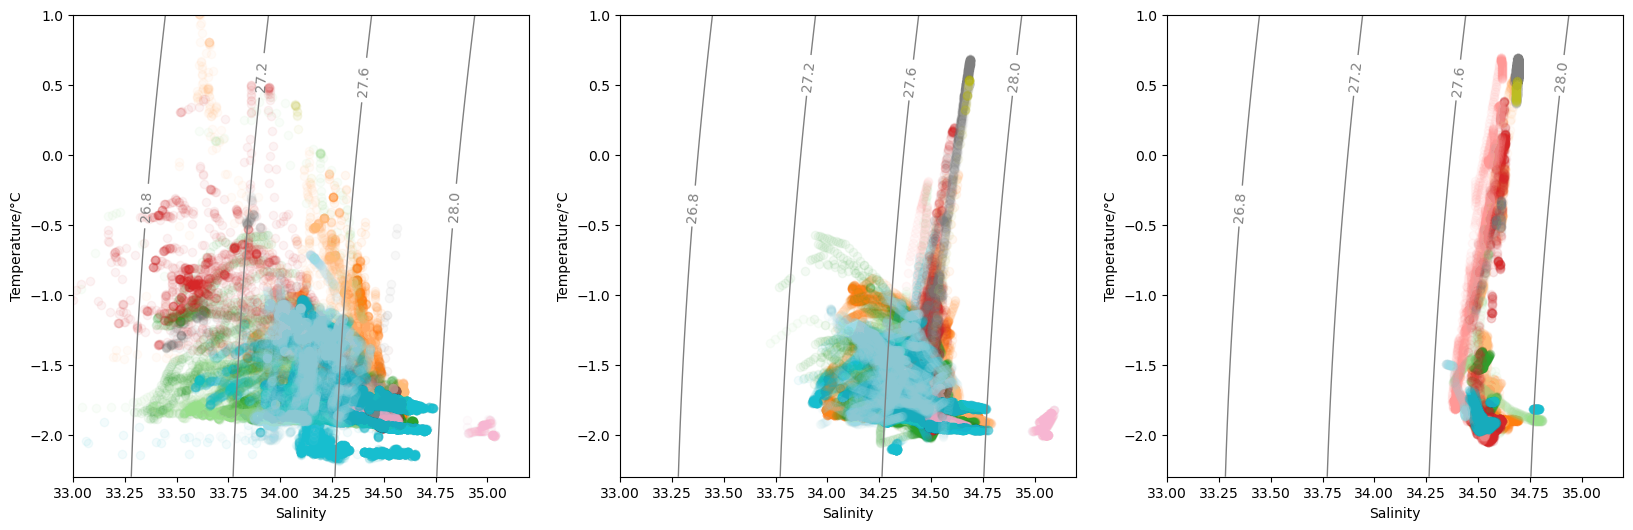

In [25]:
fig, ax = plt.subplots(1,3,figsize=(20,6))

ims=[]
def ts_plot(ax,z1,z2):
    for y in cdict.keys():
        data = ds_shelf.where(ds_shelf.year==y,drop=True).where(max_depth > z2,drop=True).sel(pres=slice(z1,z2))
        if not len(data.time) ==0:
            ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y],label=str(y.item())))

            

    tlim=[-2.3,1]
    slim=[33,35.2]
    temprange,psalrange,sig0range_ = fns.sig0range(tlim,slim)
    cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
    plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
    ax.set_xlim(slim)
    ax.set_ylim(tlim)
    ax.set_ylabel('Temperature/°C')
    ax.set_xlabel('Salinity')

ts_plot(ax[0],0,100)
ts_plot(ax[1],100,300)
ts_plot(ax[2],300,600)
